# Classical vs Quantum Classifier on `make_moons` Dataset

This notebook compares **classical machine learning classifiers** with **quantum machine learning models**.  
We use the `make_moons` dataset as a simple, non-linearly separable problem.

Classifiers included:
1. Classical Logistic Regression
2. Classical Multi-Layer Perceptron (MLP)
3. Variational Quantum Classifier (VQC)
4. Quantum Kernel Classifier (QKC)

Steps:
- Generate and visualize dataset
- Train each classifier
- Compare decision boundaries and test accuracies


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

import pennylane as qml
from pennylane import numpy as pnp

np.random.seed(0)


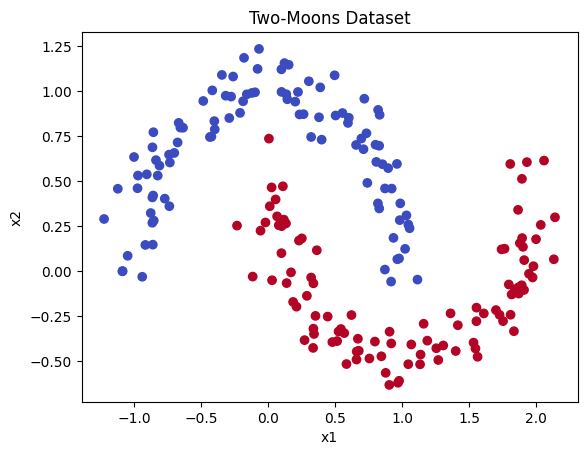

In [7]:
# Generate moons dataset
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Visualize dataset
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
plt.title("Two-Moons Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


In [8]:
# Train logistic regression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
acc_logreg = accuracy_score(y_test, y_pred_logreg)

print(f"Logistic Regression Test Accuracy: {acc_logreg*100:.2f}%")


Logistic Regression Test Accuracy: 90.00%


In [9]:
# Train a small MLP
mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=500)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
acc_mlp = accuracy_score(y_test, y_pred_mlp)

print(f"MLP Test Accuracy: {acc_mlp*100:.2f}%")


MLP Test Accuracy: 82.50%


/home/codespace/.local/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [10]:
# Define a 2-qubit device
dev = qml.device("default.qubit", wires=2)

def encode_data(x):
    qml.RX(x[0], wires=0)
    qml.RY(x[1], wires=1)

def variational_circuit(weights, x):
    encode_data(x)
    qml.CNOT(wires=[0,1])
    qml.Rot(weights[0], weights[1], weights[2], wires=0)
    qml.Rot(weights[3], weights[4], weights[5], wires=1)

@qml.qnode(dev)
def circuit(weights, x):
    variational_circuit(weights, x)
    return qml.expval(qml.PauliZ(0))

def predict_vqc(weights, X):
    preds = [np.sign(circuit(weights, x)) for x in X]
    return (np.array(preds) > 0).astype(int)

def cost(weights, X, y):
    preds = [circuit(weights, x) for x in X]
    probs = (pnp.array(preds) + 1) / 2
    return -pnp.mean(y * pnp.log(probs + 1e-6) + (1 - y) * pnp.log(1 - probs + 1e-6))

# Train VQC
weights = 0.01 * pnp.random.randn(6, requires_grad=True)
opt = qml.GradientDescentOptimizer(stepsize=0.4)
epochs = 30
for epoch in range(epochs):
    weights, curr_cost = opt.step_and_cost(lambda w: cost(w, X_train, y_train), weights)

y_pred_vqc = predict_vqc(weights, X_test)
acc_vqc = accuracy_score(y_test, y_pred_vqc)
print(f"VQC Test Accuracy: {acc_vqc*100:.2f}%")


VQC Test Accuracy: 65.00%


In [11]:
# Simple 2-qubit quantum feature map
def feature_map(x):
    qml.RX(x[0], wires=0)
    qml.RX(x[1], wires=1)
    qml.CNOT(wires=[0,1])
    qml.RZ(x[0]*x[1], wires=0)

@qml.qnode(dev)
def kernel_circuit(x):
    feature_map(x)
    return qml.state()

# Precompute training states
train_states = [kernel_circuit(x) for x in X_train]
test_states = [kernel_circuit(x) for x in X_test]

# Compute kernel matrices
K_train = np.array([[np.abs(np.vdot(s1, s2))**2 for s2 in train_states] for s1 in train_states])
K_test = np.array([[np.abs(np.vdot(s1, s2))**2 for s2 in train_states] for s1 in test_states])

from sklearn.svm import SVC
svm = SVC(kernel='precomputed')
svm.fit(K_train, y_train)
y_pred_qkc = svm.predict(K_test)
acc_qkc = accuracy_score(y_test, y_pred_qkc)
print(f"QKC Test Accuracy: {acc_qkc*100:.2f}%")


QKC Test Accuracy: 87.50%


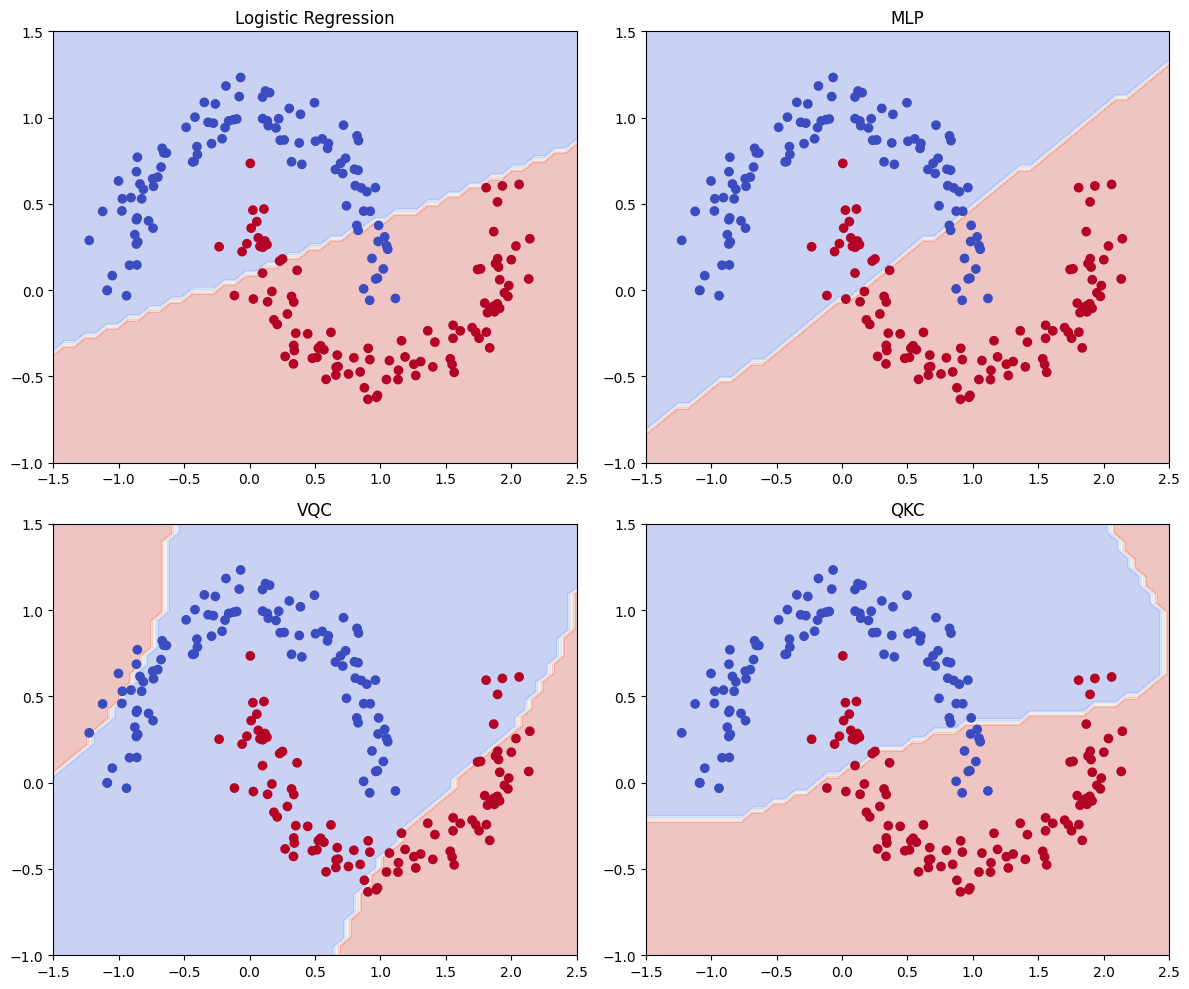

In [14]:
# Meshgrid for visualization
xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 50), np.linspace(-1, 1.5, 50))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Logistic Regression
Z_logreg = logreg.predict(grid_points).reshape(xx.shape)
# MLP
Z_mlp = mlp.predict(grid_points).reshape(xx.shape)


# Vectorized VQC prediction for grid points
def predict_vqc_grid(weights, X_grid):
    return np.array([np.sign(circuit(weights, x)) for x in X_grid] > 0, dtype=int)

def predict_vqc_grid(weights, X_grid):
    preds = np.array([np.sign(circuit(weights, x)) for x in X_grid])
    # Map {-1, +1} to {0, 1}
    return (preds > 0).astype(int)

Z_vqc = predict_vqc_grid(weights, grid_points).reshape(xx.shape)

# Precompute training states
train_states = np.array([kernel_circuit(x) for x in X_train])

# Compute overlaps in a vectorized way
def compute_kernel_overlap(grid_points, train_states):
    n_grid = len(grid_points)
    n_train = len(train_states)
    kernel_matrix = np.zeros((n_grid, n_train))
    for i, gp in enumerate(grid_points):
        gs = kernel_circuit(gp)
        for j, ts in enumerate(train_states):
            kernel_matrix[i, j] = np.abs(np.vdot(gs, ts))**2
    return kernel_matrix

K_grid = compute_kernel_overlap(grid_points, train_states)
Z_qkc = svm.predict(K_grid).reshape(xx.shape)

# Plot all decision boundaries
fig, axs = plt.subplots(2,2, figsize=(12,10))
for ax, Z, title in zip(axs.ravel(), [Z_logreg, Z_mlp, Z_vqc, Z_qkc],
                        ["Logistic Regression","MLP","VQC","QKC"]):
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
    ax.set_title(title)
plt.tight_layout()
plt.show()
